## Model Explainability (SHAP Analysis)

This notebook focuses on interpreting the trained customer churn model using SHAP (SHapley Additive exPlanations).

### Objectives:
- Understand which features influence churn predictions
- Analyze feature impact and direction
- Gain business insights from model behavior

### Steps:
1. Load the trained pipeline (`best_churn_pipeline.pkl`)
2. Load the processed dataset
3. Separate input features (X) and target variable (y)
4. Prepare data for SHAP-based explainability

This helps move beyond model accuracy to understand *why* predictions are made.

In [13]:
import joblib
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import shap


best_pipeline = joblib.load('../models/best_churn_pipeline.pkl')
df = pd.read_csv('../data/processed_data.csv')

X = df.drop(columns=['churn', 'customer_id'])
y = df['churn']

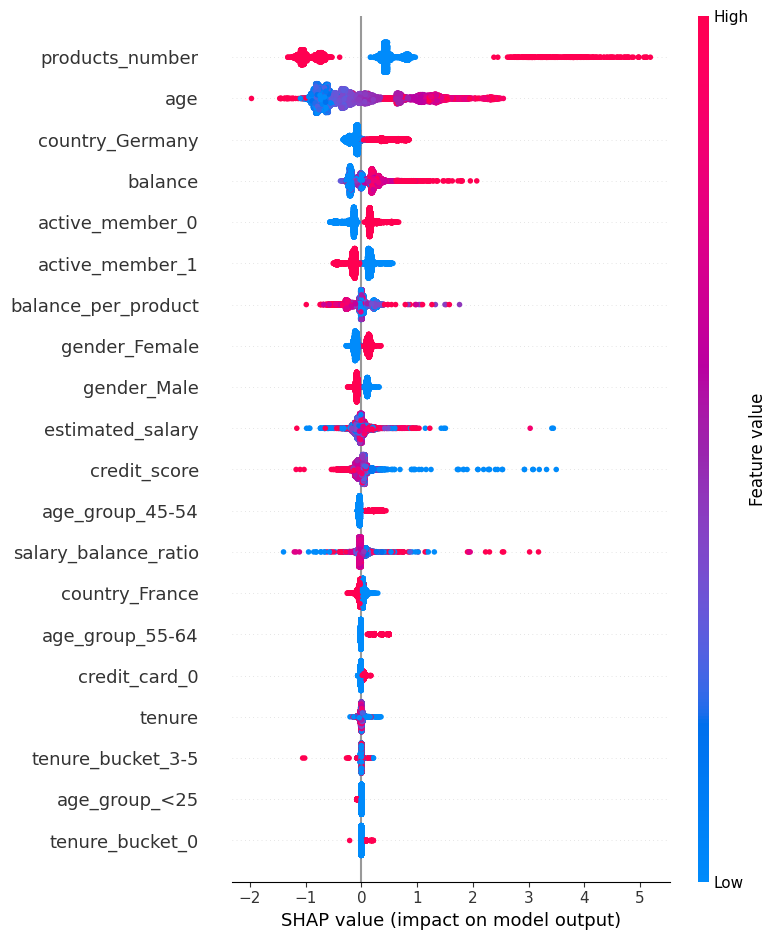

In [11]:
# Get feature names
preprocessor = best_pipeline.named_steps['preprocessor']
num_feats = preprocessor.transformers_[0][2]
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X)
num_feats = numeric_features
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feats = cat_encoder.get_feature_names_out(categorical_features)

feature_names = list(num_feats) + list(cat_feats)

# SHAP plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)